# Logistic Regression Model For Breast Cancer Diagnosis

## 1 - Introduction

### 1.1 - Clinical Background
In 2020, it is estimated that cancer led to 2.3 million new cases and 685,000 deaths.  
By 2040, the burden from breast cancer is predicted to increase to over 3 million new cases and 1 million deaths every year because of population growth and aging alone. ([Arnold et al. 2022](https://pmc.ncbi.nlm.nih.gov/articles/PMC9465273/))
Worldwide breast cancer is the leading type of cancer in women, accounting for 25% of all cases.


These numbers underscore the critical need to **enhance diagnostic processes**, in terms of efficiency, quality, and rapidity.  
Early and widespread diagnosis is essential to enable timely intervention, and machine learning techniques, working alongside clinicians, hold significant potential for this life‑saving process.


One major limitation of machine and statistical learning in diagnosis is their **lack of interpretability**.   
Often described as *'black boxes'*, these models provide no insight into the decision process that led to their prediction, which restricts their ability to effectively support clinical decision-making.

#### 1.2 - The Data : Breast Cancer Wisconsin Diagnostic Dataset
The Breast Cancer Wisconsin (Diagnostic) Dataset is a real clinical dataset derived from digitized images of fine‑needle aspirates of breast masses, where each sample is labeled as benign or malignant and described by 30 numerical features capturing cell‑nuclei shape and texture.  
It can be found at : [Data](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic)

#### 1.3 - The Model
Many models can be used for such a task, to cite a few :
- Decision Tree
- Support Vector Machine
- K-Mean clustering Algorithm
- Logistic Regression
- Neural Networks


Here, we will use Logistic Regression. Different reasons justify this choice. First, as we want to build a clinical tool that could support clinician decisions, interpretability is essential. This eliminates Neural networks, which often are too obscure with respect to their decision process. An advantage on the side od Logistic Regression is its ability to give a probabilistic prediction (which a decision tree or vector machine can not give). Eventually, this model can easily take in new data, this will facilitate further improvements.

In [17]:
# Necessary Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# For reproducibility
seed = 42

# Load Data
df = pd.read_csv('./Data/breast_cancer.csv')

# Print the first few rows
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Before diving into further analysis and processing, we must start by checking how clean is the data. This is the occasion to get a bit more information on the dataset.

In [18]:
# Check for missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

As it is a dataset often used for machine learning training, it has already been cleaned and there is no null or undefined values.  
Among the 30 parameters (32 rows among which one is id and another diagnostic) of our 569 samples, none are non defined.  
Further exploration is required to gain familiarity with the dataset; to do so, we will apply df.describe( wich will give us a synthetic statistical analysis of it).

In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


This gives a detailed statistical overview of the data. Nevertheless, it is not a great format for human understanding. One can use visuals and plots to improve understanding of the dataset. This is the subject of the next section.

#### 2.2 - Deepening understanding with plots

##### 2.2.1 - Diagnostic Distribution
Now that the structure of the data is understood, let's plot what we will then try to infer : the diagnosis.  


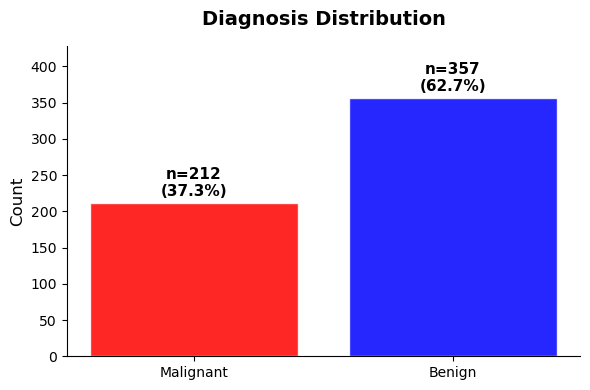

In [20]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['diagnosis'].value_counts()
colors = ['red', 'blue']
bars = ax.bar(['Malignant', 'Benign'], [counts['M'], counts['B']], color=colors, alpha=0.85, edgecolor='white')

for bar, count in zip(bars, [counts['M'], counts['B']]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'n={count}\n({count/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('Diagnosis Distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Count', fontsize=12)
ax.set_ylim(0, max(counts) * 1.2)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('Images/diagnosis_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

##### 2.2.2 - Features-Diagnostic Relationship
One important aspect is the fact that the benign group is much greater han the malignant one. However, if one wants to maximize recall and reduce false negative, malignant data points should hold a greater weight in the learning process.  
This issue wil be solved in part 4.

Exploration of the correlation between different sets of parameters and diagnostic is the first step towards a learning approach for diagnosis.

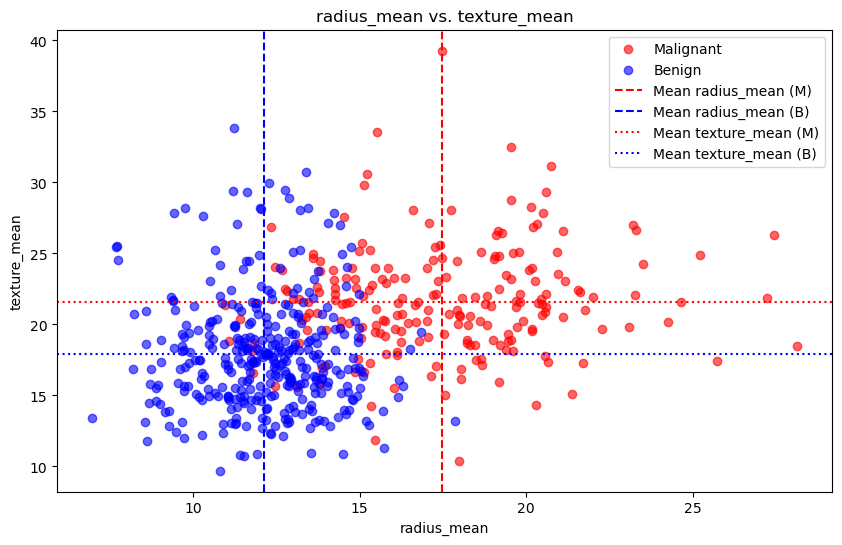

In [21]:
data_m = df[df['diagnosis'] == 'M']
data_b = df[df['diagnosis'] == 'B']

# Fucntion to print a histogram of 2 parameters
def plot_hist(df, param1, param2):

    df_m, df_b = df[df['diagnosis'] == 'M'], df[df['diagnosis'] == 'B']

    # Check parameters validity
    if param1 not in df.columns or param2 not in df.columns:
        print("Error, one of the parameter is not valid")
        return

    # Make a scatter plot 
    plt.figure(figsize=(10, 6))
    plt.scatter(df_m[param1], df_m[param2], color='red', label='Malignant', alpha=0.6)
    plt.scatter(df_b[param1], df_b[param2], color='blue', label='Benign', alpha=0.6)

    # Add means lines
    plt.axvline(df_m[param1].mean(), color='red', linestyle='--', label=f'Mean {param1} (M)')
    plt.axvline(df_b[param1].mean(), color='blue', linestyle='--', label=f'Mean {param1} (B)')
    plt.axhline(df_m[param2].mean(), color='red', linestyle=':', label=f'Mean {param2} (M)')
    plt.axhline(df_b[param2].mean(), color='blue', linestyle=':', label=f'Mean {param2} (B)')

    # Add titles and labels
    plt.title(f'{param1} vs. {param2}')
    plt.xlabel(f'{param1}')
    plt.ylabel(f'{param2}')
    plt.legend()
    plt.savefig(f'Images/{param1}_vs_{param2}.png', dpi=150, bbox_inches='tight')
    plt.show()

# Example

plot_hist(df, 'radius_mean', 'texture_mean')

As anticipated from a biological standpoint, the analysis reveals a strong correlation between the radius mean and a malignant cancer diagnosis. This aligns with the well-documented tendency of malignant cells to exhibit uncontrolled growth, a hallmark of cancer progression due to the loss of sensitivity to regulatory metabolic pathways.  

Additionally, a weaker yet noticeable correlation seems to emerge between texture and diagnostic outcomes. Further probabilistic analysis is required to validate these preliminary findings and assess their significance.

Note that this 2D plot is not inherently special, it could be a single dimension, or more than 2 (plotting x distinct features). We chose this 2D visualization for its simplicity and superior readability.

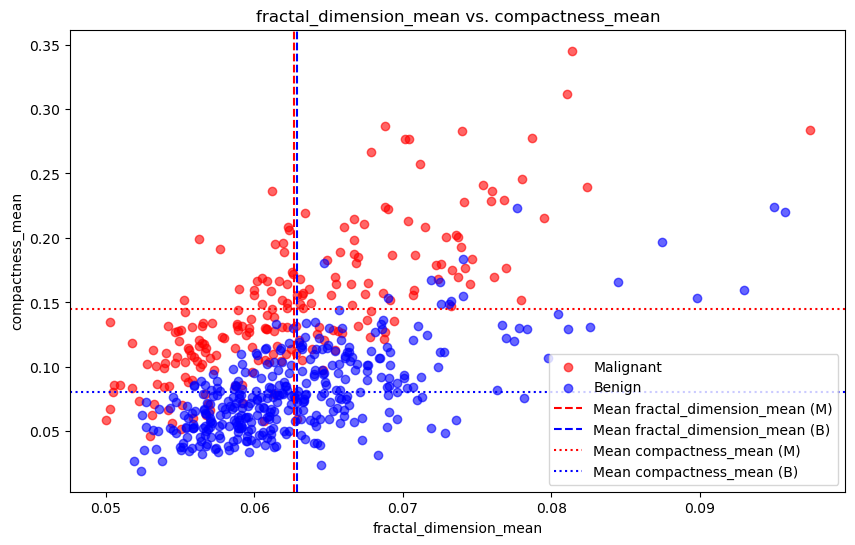

In [22]:
# histogram of fractal dimension and compactness
plot_hist(df, 'fractal_dimension_mean', 'compactness_mean')

The second plot suggests that compactness may serve as a discriminative feature for diagnosis, given the visible separation between malignant and benign cases. However, the fractal dimension seems to offer limited diagnostic value on its own, as its distribution overlaps significantly between the two groups.

This qualitative and visual approach is great to develop intuition and understanding, but it is not scallable as comparing every pair of parameters among the 30 that we have would require 435 plots.  
This is why the next part will focus on developping and automated way to evaluate the relevance of each feature.

# 3 - Finding Relevant Features

Finding the most decisive parameters allows to develop lighter and easier to understand clinical products.

### 3.1 - Data Preprocessing

In [23]:
# Map diagnosis to binary (Malignant = 1, Benign = 0)
df.drop('id', axis=1, inplace=True)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

### 3.2 - Best Features Identification

Feature selection is an important step in building a classification model. It is advantageous to limit the number of input attributes in a classifier in order to have good predictive and less computationally intensive models. Another advantage of limiting the number of features is that it decreases the chances of overfitting (often caused by too complex models that fit too closely the training data but do not generalize well on unseen data).


In order to evaluate each feature relevance, we will measure their correlation thanks to a correlation matrix.

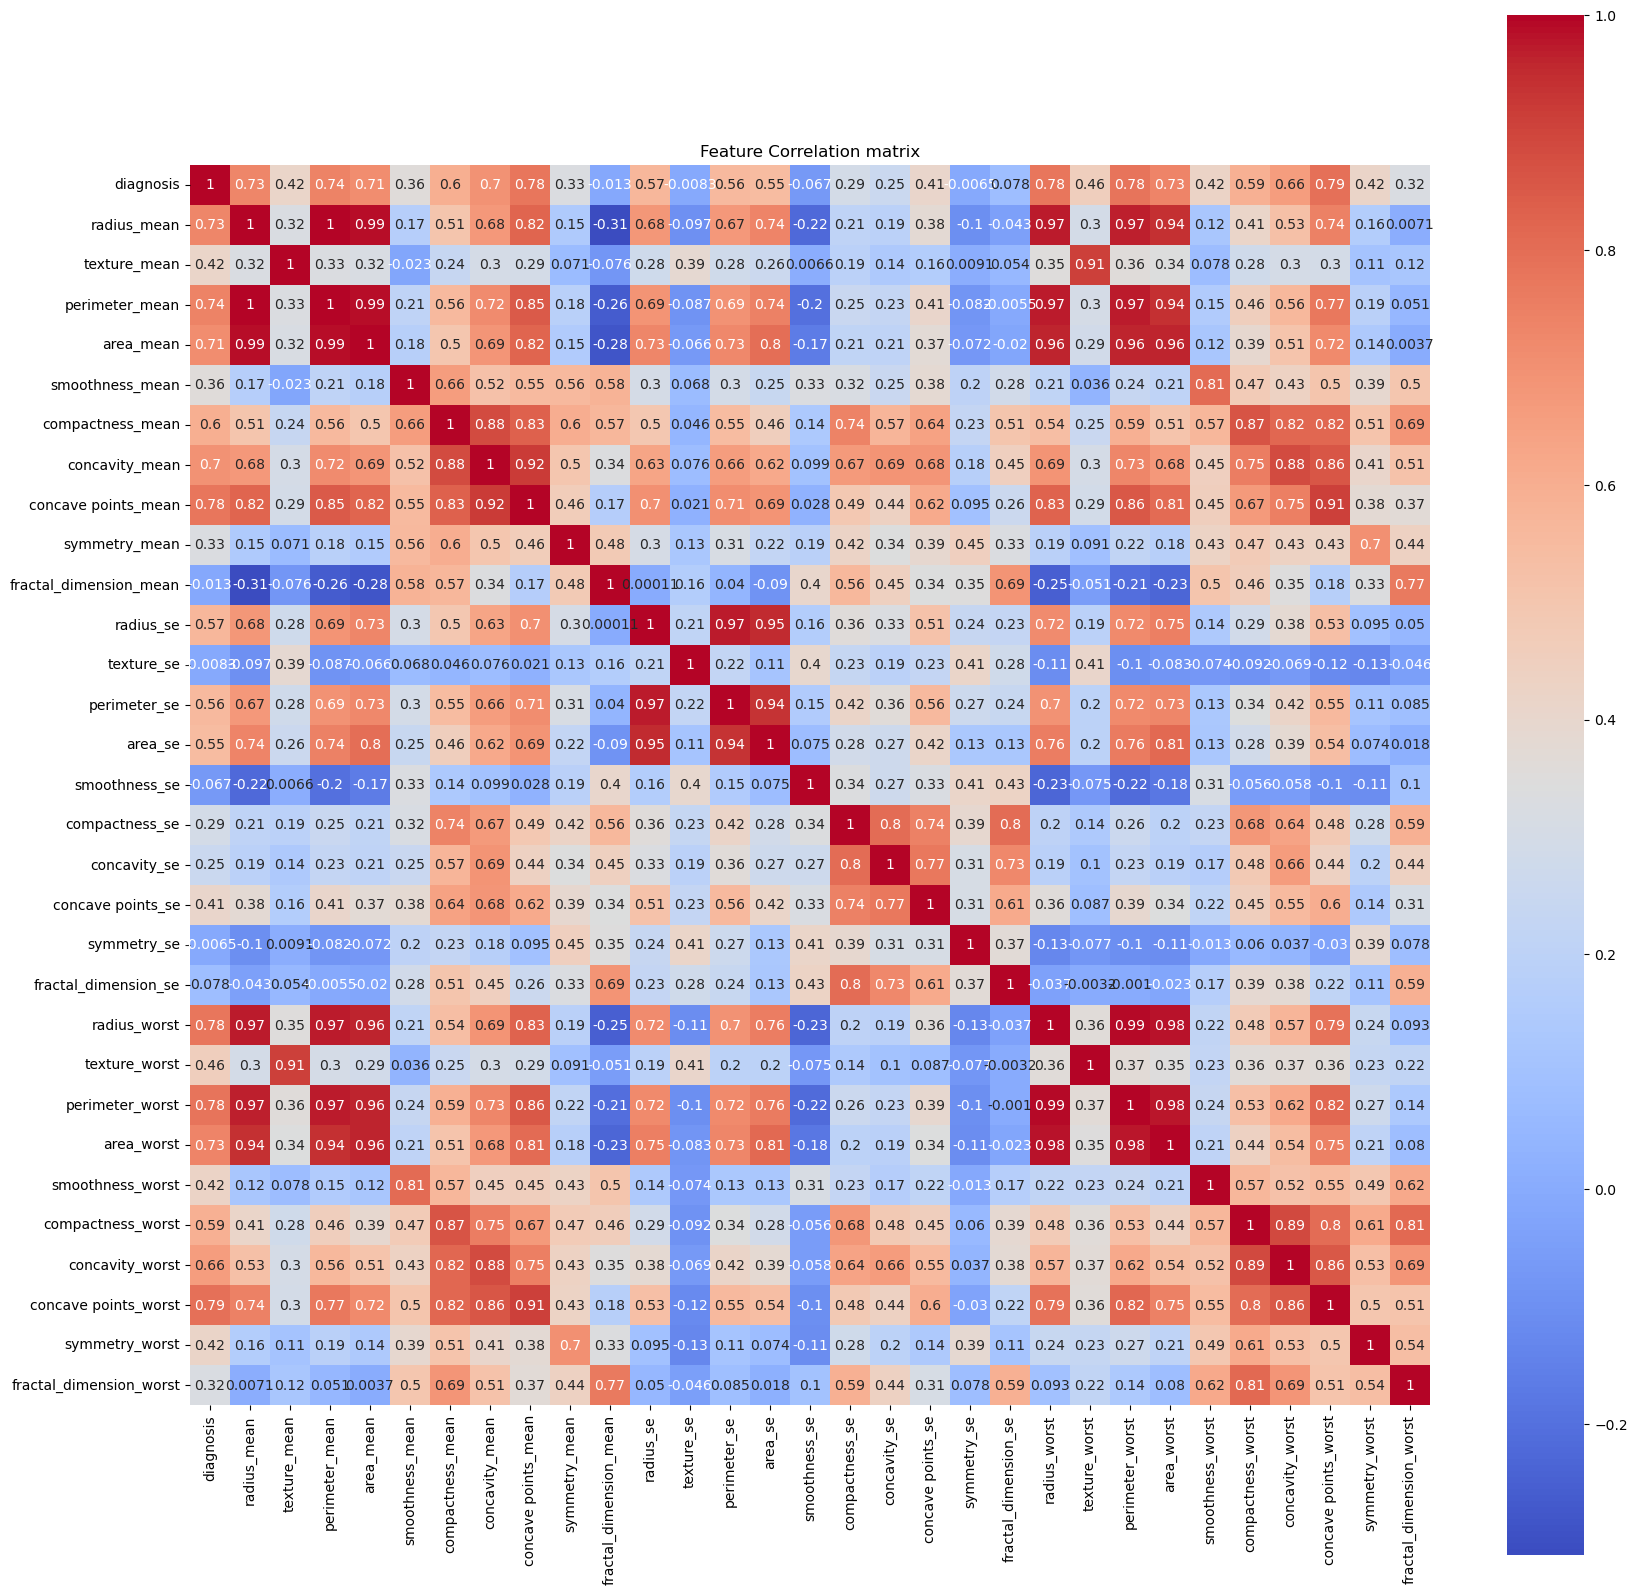

In [24]:
corr = df.corr()
plt.figure(figsize=(20, 20))
sns.heatmap(corr, annot=True, cmap='coolwarm', cbar=True, square=True)
plt.title('Feature Correlation matrix')
plt.show()

As expected, some features are highly correlated (the pairs whose intersection is represented as deep red); for instance, area and radius are highly correlated, which should not come as a surprise.   
The most important column to look at is the first one as it gives the correlation of each features with the taget variable.  
As we want our model to be as simple to enhance interpretability while reducing the risk of overfitting, we will only work with the features that have a absolute correlation with the diagnosis above 2.0

/tmp/ipykernel_193892/2937752378.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=relevant_features.values, y=relevant_features.index, orient='h', palette='viridis')


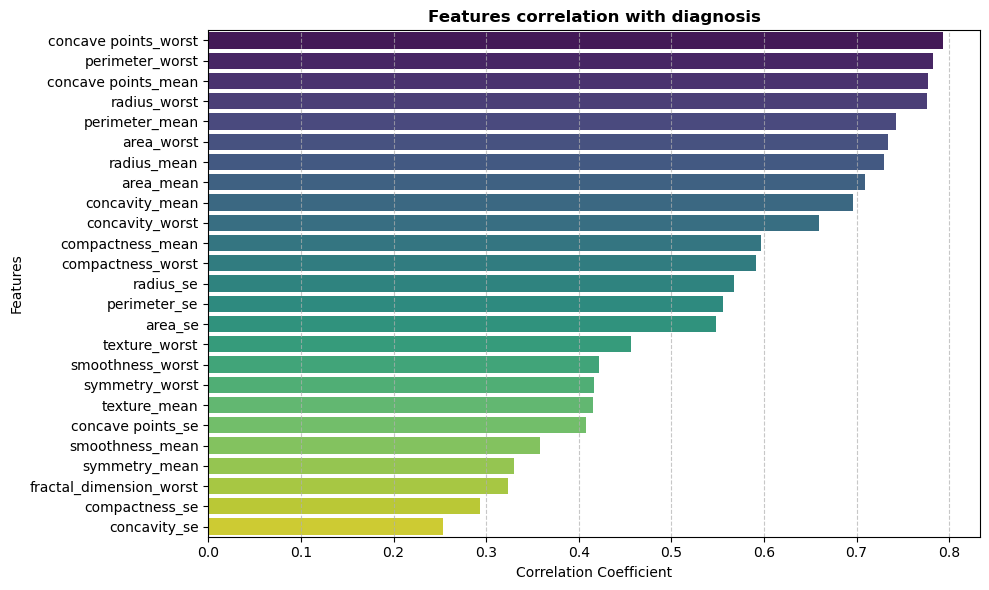

In [25]:
# Take the absolute value of the correlation
corr_target = abs(corr['diagnosis'])
# identify features with a correlation greater than 0.2 with the target variable
relevant_features = corr_target[corr_target > 0.2].sort_values(ascending=False)

relevant_features = relevant_features.drop('diagnosis') # Remove the target variable

# Print the resulting relevant features
plt.figure(figsize=(10, 6))
sns.barplot(x=relevant_features.values, y=relevant_features.index, orient='h', palette='viridis')
plt.title("Features correlation with diagnosis", fontweight='bold')
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Which leaves us with 25 features, the most correlated to the diagnosis.

### 3.3 - Data Split
An important step in machine learning consist in splitting the data. Indeed, the model needs to be train on as much data as possible, in general, the more the better. But an issue arises when one needs to evaluate the validity of the model, as all the data as been used to train the model, how can we evaluate the capacity of the model ?  
Teting it on data that it as already seen will falsly and systematically increase the performance results as the model integrated those data points. The solution is to set aside a subset of the data, that the model won't see at all until the end of the process, such that it can be tested on new, unknonw data.  
The general split consists in 80% training and 20% testing.

In [26]:
# Separate features and target
X = df[relevant_features.index]
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)



### 3.4 - Data Standardization

To ensure accurate results, we first normalize the features. Without normalization, a feature measured in nanometers could artificially dominate over the same feature measured in meters, only due to scale differences. Normalization eliminates this bias.

Normalisation : Y = $\frac{X - \bar{X}}{sd}$ _where $\bar{X}$ is the mean of the random variable X and sd is its standard deviation_

This standarisation method can also be found under the name of z-score standarisation. It refers to the number of standard deviations by which the value of a datapoint is above or below the mean value of the observed population.

In [27]:
def Standardize(X_train, X_test):
    features = X_train.columns
    X_train[features] = (X_train[features] - X_train[features].mean()) / X_train[features].std()
    X_test[features] = (X_test[features] - X_test[features].mean()) / X_test[features].std()
    return X_train, X_test

X_train, X_test = Standardize(X_train, X_test)


## 4 - The Model : Logistic Regression

#### 4.1 - Theoretical Understanding

##### 4.1.1 - What does Logistic Regression Mean ?

Before starting the implementation, let's undersand the theoretical background that supports our model.  
Logistic Regression is a statistical model that aims to predict the log-odds of an event as a linear combination of parameters.


First, we need to clarify some of the obscure terms we used.  
- Odds : $\frac{p}{1 - p}$, where p is the probability of the event happening (in our case, the cell being malignant), and (1-p) the probability of the event not happening (the cell being benign).
- log-odds : $z(p) = log(\frac{p}{1 - p})$, simply the logarithm of the Odds, introduced above.
- Linear Combination : Y = $b + w_1 x_1 + w_2 x_2 + ... + w_n x_n$ where $w_i$ and $b$ are the 'weights' learned by the model during learning and X is the features matrix. The linear combination consist in n weights and a bias (that can be considered as a weight itself, associated to a constant parameter equal to 1). This linear combination can therefore be represented as : $Z = X*W + b$ 
- Logistic function : $p(z) = \frac{1}{1 + e^z}$ 



To sum up : logistic regression models the log-odds of a binary outcome as a linear function of features, then transforms it into a probability using the sigmoid, enabling both interpretation and classification -which just require to set a probability treshold-.  


${\displaystyle p={\frac {1}{1+b^{-(\beta _{0}+\beta _{1}x_{1}+\beta _{2}x_{2}+\cdots +\beta _{m}x_{m})}}}}$


Sanity check : Linear Regression can output any value $\in (-\infty, +\infty)$. However, we want it to return a probability. To do so, we can leverage the properties of the logistic function which maps all the real values to the $[0, 1]$ interval. In other words, it can transform our unbound prediction into a probability.  
The inverse transformation to this function is the log-odds, such that we can consider that the linear combinaison gives the log-odds of the sample belonging to the malignant class.


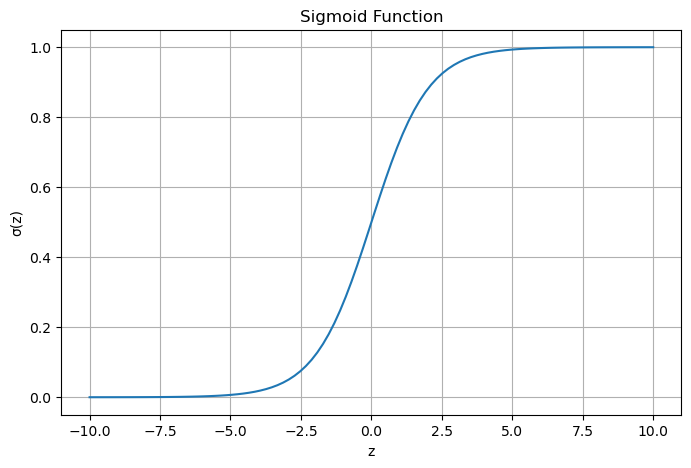

In [28]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

# plot sigmoid
z = np.linspace(-10, 10, 100)
plt.figure(figsize=(8, 5))
plt.plot(z, sigmoid(z))
plt.title('Sigmoid Function')
plt.xlabel('z')
plt.ylabel('σ(z)')
plt.grid(True)
plt.show()

In order to learn, we need a way to tell the model how good its prediction are. This is done by introducing a loss function. It is a function that penalise the model for bad prediction. Ideally, it penalises stronger when the model makes a bad guess while displaying strong confidence, such that the model adjust to make better guess.  
The singularity of our case is the fact that our target -the diagnosis- is binary and our prediction is probabilistic. Therefore, it is important that the loss function is sensitive to the certainty of predictions.

##### 4.1.2 - The Loss Function

First, let's define the basic notations we will use :
- N is the number of samples
- $y_i$ is the actual binary diagnosis of the i-th observation (1 if malignant, 0 if not)
- $p_i$ is the predicted probability that the i-th sample is malignant


We can now proceed to the research of our loss function.  
First, one could think about evaluating the likelyhood of the observed data given the probabilities given by our model. This can be obtained the following way :  
$P(y_i|x_i) = p_i^{y_i} + (1-p_i)^{1-y_i}$  


Applied over N independant data points it gives:  
$L(w) = \prod_{i=1}^N P(y_i|x_i) = \prod_{i=1}^N [p_i^{y_i} + (1-p_i)^{1-y_i}]$


To simplify the product we take the log likelihood which transforms it in a sum. It is easier to manipulate, especially when it will come down to derivatives.  
$LogL(w) = \sum_{i=1}^N y_ip_i + (1-y_i)(1-p_i)$


We now have a likelihood estimate. To improve a model, we would aim to maximize it as a better likelihood means more accurate predictions. Yet, mathematicians prefer minimization problems as they developped many tools to handle this kind of problem. It can easily be fixed as we can make our likelihood estimate a loss function by putting a negative sign ahead. Thus our maximisation problem becomes a minimisation one as we want to reduce the loss as much as possible to guarantee accurate predictions. Plus, we can divide it by the number of samples to facilitate the later computations, this last step do not change anything to the behavior of the loss function.

$LogLoss = -\frac{1}{N}\sum_{i=1}^N(y_i log(p_i) + (1-y_i)log(1 - p_i))$ 

We will now refer to the loss function as L(W, b) and write it in a more explicit manner : 


$L(W, b) = -\frac{1}{N}\sum_{i=1}^N(y_i log(f_{w,b}(x_i)) + (1-y_i)log(1 - f_{w,b}(x_i)))$


where $f_{w,b}(x)$ is the predicted probability of sample $x_i$ belonging to the malignant class.

##### 4.1.3 - The Backward Pass and Weight Update
The backward pass calculates the gradients of the cost function with respect to the parameters (W,b). These gradients are essential for updating the model parameters during training.


- $\frac{\delta L(w,b)}{db} = \sum_{i=1}^N (y_i - p_i)$


- $\frac{\delta L(w,b)}{dW} = \sum_{i=1}^N (y_i - p_i)x_k$


Uptdating the weight vector W and bias b is done through gradient descent. Given a learning rate $\alpha$, the update equations for parameters are:


- $W \leftarrow W - \alpha \frac{\delta L(w,b)}{dW}$


- $b \leftarrow b - \alpha \frac{\delta L(w,b)}{db}$


The learning process consist in the iterative update of the weight vector and the bias following this gradient descent rule. 


By iteratively performing the forward pass, computing the cost, performing the backward pass, and updating the parameters, the logistic regression model learns to make better predictions and fit the data.




In [29]:
class LogisticModel:
    def __init__ (self, learning_rate=0.01, n_iterations=1000, threshold=0.5):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.threshold = threshold
        self.W = None
        self.b = 0

    def forward(self, X):
        linear_comb = np.dot(X, self.W) + self.b
        return sigmoid(linear_comb)

    def cost(self, y_true, y_pred):
        m = len(y_true)
        cost = - (1/m) * np.sum(y_true * np.log(y_pred + 1e-15) + (1 - y_true) * np.log(1 - y_pred + 1e-15))
        return cost

    def gradients(self, X, y_true, y_pred):
        m = len(y_true)
        dw = (1/m) * np.dot(X.T, (y_pred - y_true))
        db = (1/m) * np.sum(y_pred - y_true)
        return dw, db

    def fit(self, X, y, iterations=None, plot_cost=False):

        self.X = X
        self.y = y
        self.W = np.zeros(X.shape[1])
        self.b = 0

        if iterations is not None:
            self.n_iterations = iterations
        
        costs = []
        for i in range(self.n_iterations):

            # Forward Pass
            y_pred = self.forward(self.X)

            # Cost
            cost = self.cost(self.y, y_pred)
            costs.append(cost)

            # Gradient Descent
            dw, db = self.gradients(self.X, self.y, y_pred)
            self.W -= self.learning_rate * dw
            self.b -= self.learning_rate * db

            if plot_cost:
                if i % 100 == 0:
                    cost = self.cost(y, y_pred)
                    print(f"Iteration {i}, Cost: {cost:.4f}")

        if plot_cost:
            # Plot a line
            plt.plot(costs)
            plt.title('Cost over iterations')
            plt.xlabel('Iterations')
            plt.ylabel('Cost')
            plt.grid()
            plt.show()

    def predict(self, X, threshold=None):
        if threshold is not None:
            self.threshold = threshold
        linear_comb = np.dot(X, self.W) + self.b
        y_pred = sigmoid(linear_comb)
        return (y_pred >= self.threshold).astype(int)
    
    def predict_probas(self, X):
        linear_comb = np.dot(X, self.W) + self.b
        return sigmoid(linear_comb)

    def score_report(self, y_true, y_pred):
        print(classification_report(y_true, y_pred))
        print("Confusion Matrix:")
        print(confusion_matrix(y_true, y_pred))

Here is our model, ready to be trained. 

Iteration 0, Cost: 0.6931
Iteration 100, Cost: 0.2569
Iteration 200, Cost: 0.1954
Iteration 300, Cost: 0.1670
Iteration 400, Cost: 0.1499
Iteration 500, Cost: 0.1383
Iteration 600, Cost: 0.1297
Iteration 700, Cost: 0.1232
Iteration 800, Cost: 0.1179
Iteration 900, Cost: 0.1135


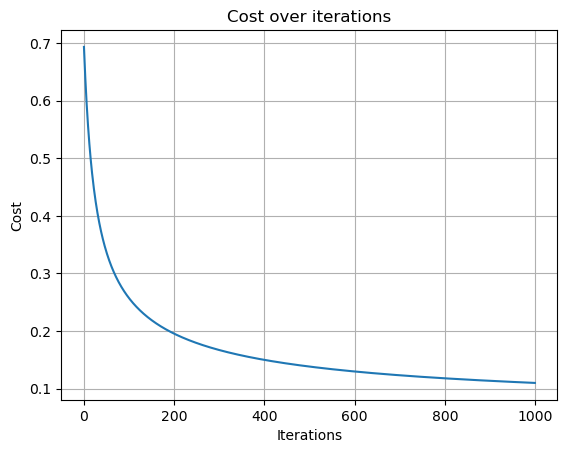

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        71
           1       1.00      0.93      0.96        43

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Confusion Matrix:
[[71  0]
 [ 3 40]]


In [30]:
# Train the model
model = LogisticModel(learning_rate=0.01, n_iterations=1000)
model.fit(X_train.values, y_train.values, plot_cost=True)
y_pred = model.predict(X_test.values)
model.score_report(y_test.values, y_pred)

Visualisation can help us better understand how this model works. 
In fact, it draws a decision boundary in the feature space.  
In order to make it 2 dimensional, we will use the two principal components of the features space. Principal components are new ortogonal dimensions that are made from a linear combination of the features. The first principal component is the axes along which most of the data variance is found, the second principal component is the ortogonal axe to the first one that shows the most variance and so on.

Therefore, we will define The two most informative axes and train the model on those, such that it will approximate the behavior of our real model but in 2D. This will allow us to plot an approximation of our model's decision boundary, in 2D.

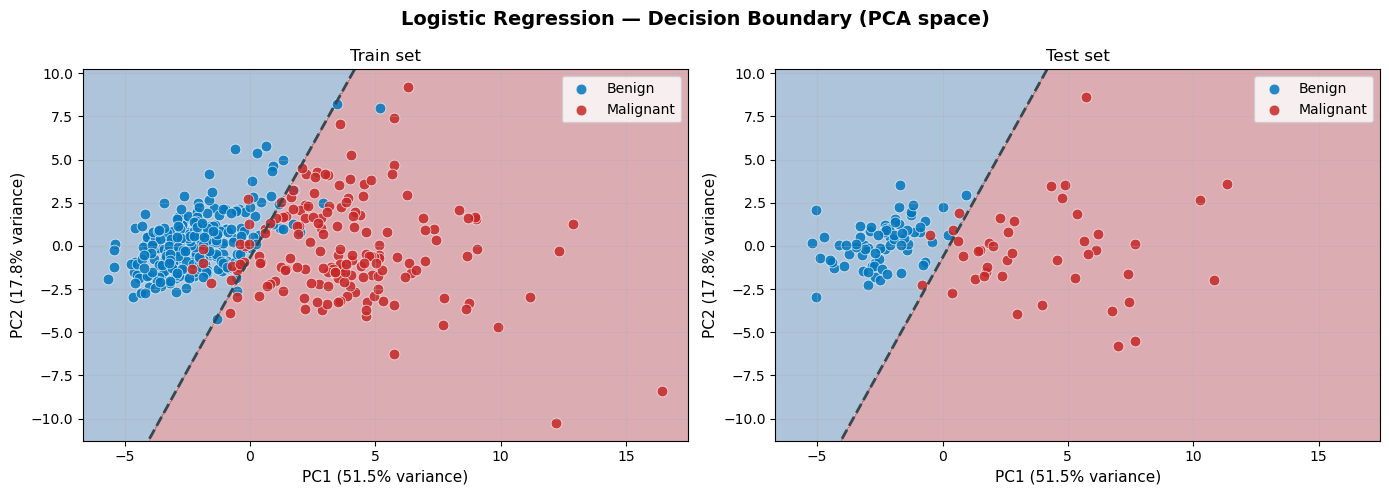

In [31]:
from sklearn.decomposition import PCA

# 1. PCA fit on train only (no leakage)
pca = PCA(n_components=2)
pca.fit(X_train)  # fit sur train uniquement
X_train_pca = pca.transform(X_train)
X_test_pca  = pca.transform(X_test)

# 2. Train a new model on the PCA space (2 features)
model_pca = LogisticModel(learning_rate=0.01, n_iterations=1000)
model_pca.fit(X_train_pca, y_train.values)

# 3. Fonction 
def plot_decision_boundary(model, X, y, title="Decision Boundary", resolution=500):
    # Colors
    colors      = ['#4FC3F7', '#EF9A9A']   # blue=benign, red=malignant
    boundary_c  = '#37474F'
    scatter_c   = ['#0277BD', '#C62828']

    # Grid covering space
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx1, xx2 = np.meshgrid(
        np.linspace(x1_min, x1_max, resolution),
        np.linspace(x2_min, x2_max, resolution)
    )

    # Predict for each point on the grid
    grid = np.c_[xx1.ravel(), xx2.ravel()]  
    Z = model.predict(grid)   
    Z = Z.reshape(xx1.shape)   

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    for ax, split_X, split_y, split_name in zip(
        axes,
        [X_train_pca, X_test_pca],
        [y_train.values, y_test.values],
        ["Train set", "Test set"]
    ):
        # decision surfaces
        ax.contourf(xx1, xx2, Z, alpha=0.35, cmap=plt.cm.RdBu_r)

        # decision boundary : 0.5
        proba_grid = model.predict_probas(grid).reshape(xx1.shape)
        ax.contour(xx1, xx2, proba_grid, levels=[0.5],
                   colors=boundary_c, linewidths=2, linestyles='--')

        # Real Data Scatter
        for cls, color, label in zip([0, 1], scatter_c, ['Benign', 'Malignant']):
            mask = split_y == cls
            ax.scatter(split_X[mask, 0], split_X[mask, 1],
                       c=color, label=label, edgecolors='white',
                       linewidths=0.5, s=60, alpha=0.85)

        ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
        ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
        ax.set_title(split_name, fontsize=12)
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# 4. Call
plot_decision_boundary(model_pca, X_train_pca, y_train,
                       title="Logistic Regression — Decision Boundary (PCA space)")
